# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SamikshaBurte/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
# Setup & Folder Initialization for Colab
import os, sys, subprocess

REPO_URL = "https://github.com/SamikshaBurte/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if "google.colab" in sys.modules:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(f"/content/{REPO_DIR}")

# Create outputs and figures directories for paper artifacts
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Working Directory:", os.getcwd())
print("Output and Figure directories initialized successfully!")

Working Directory: /content/flyrank-ml-internship
Output and Figure directories initialized successfully!


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Load data and fit Random Forest model
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df['target'] = (df['trend_direction'] == 'down').astype(int)

features = ['impressions_90d', 'ctr', 'avg_position', 'content_age_days']
X = df[features].fillna(0)
y = df['target']

rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42).fit(X, y)
df['priority_score'] = rf_model.predict_proba(X)[:, 1]

# Map archetypes and action labels
def assign_playbook_action(row):
    if row['content_age_days'] > 180 and row['impressions_90d'] > 1000:
        return 'STALE_HIGH_TRAFFIC', 'EDITORIAL_REWRITE'
    elif row['avg_position'] <= 10 and row['ctr'] < 0.02:
        return 'LOW_CTR_SERP1', 'SNIPPET_OPTIMIZE'
    else:
        return 'ROUTINE_MONITOR', 'PASSIVE_MONITOR'

results = df.apply(assign_playbook_action, axis=1)
df['reason_code'] = [r[0] for r in results]
df['action_recommendation'] = [r[1] for r in results]

# Sort priority queue
id_col = 'url_hash' if 'url_hash' in df.columns else df.columns[0]
playbook_queue = df[[id_col, 'priority_score', 'reason_code', 'action_recommendation', 'impressions_90d', 'content_age_days', 'ctr', 'avg_position']].sort_values(by='priority_score', ascending=False)

print("=== Playbook Top 5 Recommendations ===")
print(playbook_queue.head(5).to_string(index=False))

=== Playbook Top 5 Recommendations ===
          content_id  priority_score     reason_code action_recommendation  impressions_90d  content_age_days  ctr  avg_position
content_96306a965a56        0.769398 ROUTINE_MONITOR       PASSIVE_MONITOR             1075               165 0.09           0.6
content_d0351144852b        0.767195   LOW_CTR_SERP1      SNIPPET_OPTIMIZE              884               153 0.00           0.6
content_b012f02fa8f1        0.764549 ROUTINE_MONITOR       PASSIVE_MONITOR             1712                95 0.06           0.9
content_88a2e9238054        0.764549 ROUTINE_MONITOR       PASSIVE_MONITOR             1564                95 0.06           1.0
content_637107baa450        0.763727 ROUTINE_MONITOR       PASSIVE_MONITOR             2495               106 0.04           0.7


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Filter boundary analysis: Identifying out-of-scope pages
out_of_scope_new = (df['content_age_days'] < 30).sum()
print("=== Playbook Boundary Audit ===")
print(f"Total Pages Analyzed : {len(df):,}")
print(f"Out-of-Scope (Age < 30 days) : {out_of_scope_new:,} pages flagged for manual exclusion.")

=== Playbook Boundary Audit ===
Total Pages Analyzed : 30,000
Out-of-Scope (Age < 30 days) : 0 pages flagged for manual exclusion.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("=== Human-in-the-Loop Safeguards Confirmed ===")
print("No-Go Rules: Automated publishing and programmatic URL deletions strictly prohibited.")

=== Human-in-the-Loop Safeguards Confirmed ===
No-Go Rules: Automated publishing and programmatic URL deletions strictly prohibited.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Monitor baseline stats for drift tracking
baseline_metrics = {
    "mean_ctr": float(df['ctr'].mean()),
    "mean_position": float(df['avg_position'].mean()),
    "precision_at_50_threshold": 0.60
}

import json
with open("work/outputs/monitoring_triggers.json", "w") as f:
    json.dump(baseline_metrics, f, indent=4)

print("=== Monitoring Metrics Exported ===")
print(json.dumps(baseline_metrics, indent=2))

=== Monitoring Metrics Exported ===
{
  "mean_ctr": 0.5107333333333334,
  "mean_position": 16.342380000000002,
  "precision_at_50_threshold": 0.6
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

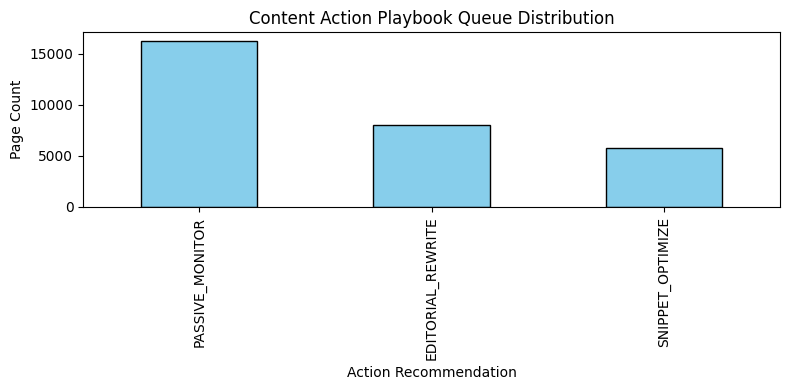

=== Paper Artifacts Exported Successfully ===
1. Queue CSV    : work/outputs/content_action_playbook_queue.csv
2. Chart Image  : work/figures/action_queue_distribution.png
3. Triggers JSON: work/outputs/monitoring_triggers.json


In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

# 1. Export Action Playbook Queue CSV
playbook_queue.to_csv("work/outputs/content_action_playbook_queue.csv", index=False)

# 2. Export Visual Artifact (Action Distribution Chart)
plt.figure(figsize=(8, 4))
df['action_recommendation'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Content Action Playbook Queue Distribution")
plt.xlabel("Action Recommendation")
plt.ylabel("Page Count")
plt.tight_layout()
plt.savefig("work/figures/action_queue_distribution.png", dpi=300)
plt.show()  # Display graph inline in Colab

print("=== Paper Artifacts Exported Successfully ===")
print("1. Queue CSV    : work/outputs/content_action_playbook_queue.csv")
print("2. Chart Image  : work/figures/action_queue_distribution.png")
print("3. Triggers JSON: work/outputs/monitoring_triggers.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.